# Các phương pháp phòng thủ trên model Logistic Regression

Sau khi đã "nhận biết" (awareness) được rằng dữ liệu huấn luyện có thể bị đầu độc bằng label flipping (xem `02-anwareness-attack.ipynb`), notebook này thử nghiệm hai hướng **phòng thủ (defend)** khác nhau, đều nhằm mục tiêu khôi phục lại accuracy gần với mức baseline sạch (~96%), ngay cả khi vẫn phải huấn luyện trên dữ liệu đã bị đầu độc ở mức nặng — **45% nhãn bị đảo** (`train_dfs["45"]`), mức cao nhất trong các thí nghiệm trước.
 
Cả hai kỹ thuật đều tự fit riêng một `StandardScaler` trên `X_train` của đúng mức % poisoned đang xét, rồi áp dụng scaler đó lên `X_test` để tạo `X_test_scaled` — đảm bảo mô hình huấn luyện và đánh giá luôn nằm trên **cùng một thang đo**, tránh sai lệch kết quả do lệch scale giữa train/test.

In [1]:
import sys, os 
from pathlib import Path

project_root = Path.cwd().parent 

os.chdir(project_root)
sys.path.append(str(project_root))

In [2]:
# Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Project
from src.defend import regularization_sweep, cleaning
from src.preprocess import X_test, y_test, train_dfs
from src.utils.math import *
from src.utils.config import config

## 1. Regularization Sweep

**Ý tưởng:** khi mô hình bị buộc học từ nhãn nhiễu, nó có xu hướng đẩy trọng số lên cao để cố "giải thích" cho cả các điểm mâu thuẫn (đã quan sát ở Case 2 của `02-anwareness-attack.ipynb`: `||w||` tăng mạnh theo % flip). Regularization (phạt độ lớn trọng số) là công cụ kinh điển để kìm hãm xu hướng này. Case này quét qua nhiều giá trị `C` (tham số nghịch đảo của độ mạnh regularization trong `sklearn` — `C` càng nhỏ, regularization càng mạnh) để xem mức regularization nào giúp mô hình "kháng cự" tốt nhất trước dữ liệu bị đầu độc 45%.

### 1.1. Chuẩn bị

Hàm `rs(poisoned_level, values)`:
- Lấy `X_train`, `y_train` từ `train_dfs[str(poisoned_level)]`, scale bằng `StandardScaler` fit riêng trên chính tập này.
- Với mỗi giá trị `C` trong `values` (lấy từ `config["C-values"]`), gọi `regularization_sweep(X_train, y_train, X_test_scaled, y_test, C)` — hàm này (định nghĩa trong `src/defend`) huấn luyện một Logistic Regression với hệ số `C` tương ứng, trả về `accuracy`, chuẩn trọng số `w_norm` trên tập test.
- Chạy với `poisoned_level = 45`.

In [3]:
def rs(poisoned_level, values):
    result = []
    
    dt_train = train_dfs[poisoned_level]

    sc = StandardScaler()

    X_train, y_train = dt_train["X"], dt_train["attack"]
    
    X_train = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    for val in values:
        acc, w_norm, _ = regularization_sweep(
            X_train, 
            y_train,
            X_test_scaled,
            y_test,
            val
        )

        result.append({
            "val": val,
            "acc": acc,
            "w_norm": w_norm
        })

    return result

In [4]:
# Chaing poisoned level to see difference 
pl_rs = 45                        
C_vals = config["C-values"]

results_C = rs(pl_rs, C_vals)
results_C_df = pd.DataFrame(results_C)

### 1.2. Vẽ biểu đồ

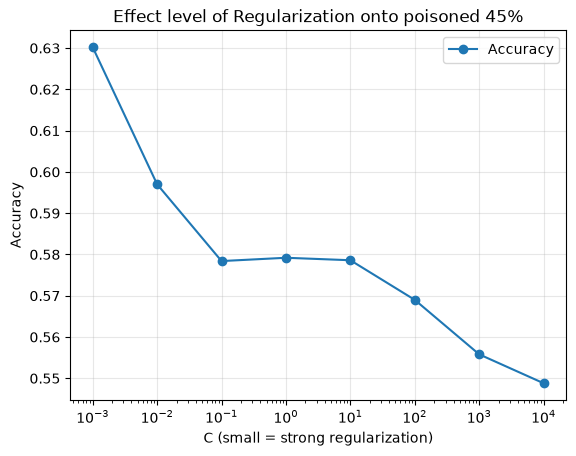

In [5]:
plt.plot(results_C_df["val"], results_C_df["acc"], marker="o", label="Accuracy")
plt.xscale("log")   
plt.xlabel("C (small = strong regularization)")
plt.ylabel("Accuracy")
plt.title(f"Effect level of Regularization onto poisoned {pl_rs}%")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 1.3. Kết luận

**Kết quả:**

| C | Accuracy |
|---|---|
| 10⁻³ (regularization rất mạnh) | **≈ 0.630** |
| 10⁻² | ≈ 0.597 |
| 10⁻¹ | ≈ 0.578 |
| 10⁰ | ≈ 0.579 |
| 10¹ | ≈ 0.578 |
| 10² | ≈ 0.569 |
| 10³ | ≈ 0.556 |
| 10⁴ (regularization gần như không có) | ≈ 0.549 |

Xu hướng chung rõ ràng: **`C` càng nhỏ (regularization càng mạnh) → accuracy càng cao**. Có một "vùng phẳng" hẹp quanh `C = 10⁻¹` đến `10¹` (accuracy gần như đi ngang ~0.578–0.579), nhưng ngoài vùng đó xu hướng vẫn tiếp diễn rõ rệt ở cả hai đầu: tăng mạnh khi `C` giảm xuống `10⁻²` và `10⁻³` (đạt đỉnh ~0.630), và **tiếp tục giảm** khi `C` tăng lên `10²`, `10³`, `10⁴` (xuống còn ~0.549) — chứ không hề "ổn định" trên toàn dải `C ≥ 1` như một mặt bằng phẳng.

Ở `C = 10⁻³`, accuracy đạt ~63%, cao hơn khoảng **8 điểm %** so với mức thấp nhất quan sát được (~55% ở `C = 10⁴`) — cho thấy regularization mạnh không chỉ tốt hơn mức "không regularization" (`C = 1`, ~58%), mà việc để regularization quá yếu (`C` rất lớn) còn khiến accuracy giảm sâu hơn nữa.

Mức cải thiện này là **có thật nhưng khiêm tốn** — regularization một mình không thể đưa accuracy quay lại gần mức 96% của mô hình sạch, cho thấy đây là một biện pháp giảm thiểu (mitigation) một phần, không phải giải pháp triệt để cho tấn công label flipping ở mức 45%.

## 2. Self - Cleaning

**Ý tưởng:** thay vì kìm hãm mô hình bằng regularization, hướng tiếp cận này cố **lọc bỏ trực tiếp** những mẫu huấn luyện bị nghi ngờ là nhãn sai, trước khi huấn luyện — dựa trên một tiêu chí nào đó (hàm `cleaning()` trong `src/defend`, ví dụ có thể dựa trên độ tin cậy dự đoán hoặc mức độ bất thường của mẫu). Tham số `keep_ratio` quyết định giữ lại bao nhiêu % dữ liệu train sau khi lọc (giữ lại các mẫu "đáng tin cậy" nhất theo tiêu chí đó).

### 2.1. Chuẩn bị

Hàm `sc(poisoned_level, krs)`:
- Lấy `X_train`, `y_train` từ `train_dfs[str(poisoned_level)]`, scale bằng `StandardScaler` riêng.
- Huấn luyện một mô hình **baseline** (`lr_p`, không lọc gì cả) trên toàn bộ `X_train` đã scale, tính `acc_b` trên `X_test_scaled` — dùng làm đường tham chiếu "trước khi lọc".
- Với mỗi `keep_ratio` trong `krs` (lấy từ `config["keep-ratios"]`), gọi `cleaning(X_train, y_train, keep_ratio)` để lọc ra `X_cleaned`, `y_cleaned`, rồi huấn luyện lại Logistic Regression trên tập đã lọc và đánh giá trên `X_test_scaled`.
- Có bước bảo vệ: nếu sau khi lọc mà `y_cleaned` chỉ còn 1 lớp duy nhất (lọc quá tay, mất hết một nhãn) thì bỏ qua điểm đó, tránh lỗi khi huấn luyện.
- Chạy với `poisoned_level = 45`.

In [6]:
def sc(poisoned_level, krs):
    result = []
    
    dt_train = train_dfs[poisoned_level]

    X_train, y_train = dt_train["X"], dt_train["attack"]

    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    lr_p = LogisticRegression(
        max_iter=config["model"]["lr"]["max-iter"],
        random_state=config["model"]["lr"]["random-state"]
    ).fit(X_train, y_train)
    acc_b = accuracy_score(y_test, lr_p.predict(X_test_scaled))

    for kr in krs:
        X_cleaned, y_cleaned = cleaning(
            X_train, 
            y_train,
            kr
        )

        # If cleaning only have one style,
        # This mean just has 0 or 1
        # We will skip this data
        if len(np.unique(y_cleaned)) < 2: continue

        lr_cleaned = LogisticRegression(
            max_iter=config["model"]["lr"]["max-iter"],
            random_state=config["model"]["lr"]["random-state"]
        ).fit(X_cleaned, y_cleaned)

        result.append({
            "val": kr,
            "acc": accuracy_score(y_test, lr_cleaned.predict(X_test_scaled)),
            "w_norm": np.linalg.norm(lr_cleaned.coef_)
        })

    return acc_b, result

In [ ]:
# Chaing poisoned level to see difference 
pl_sc = 45    
keep_ratios = config["keep-ratios"]

acc_b, result_kr = sc(pl_sc, keep_ratios)
results_kr_df = pd.DataFrame(result_kr)

### 2.2. Vẽ biểu đồ

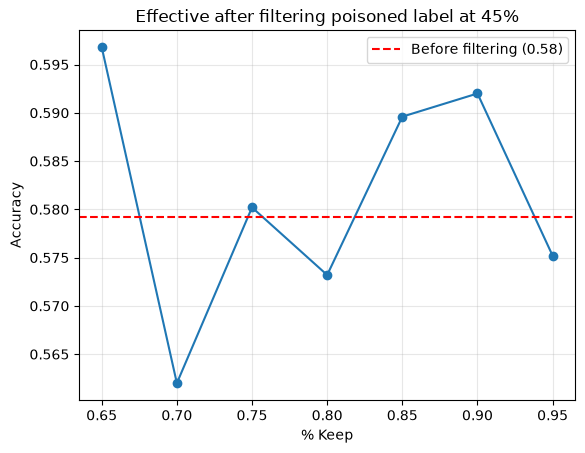

In [8]:
plt.plot(results_kr_df["val"], results_kr_df["acc"], marker="o")
plt.axhline(acc_b, color="red", linestyle="--", label=f"Before filtering ({acc_b:.2f})")
plt.xlabel("% Keep")
plt.ylabel("Accuracy")
plt.title(f"Effective after filtering poisoned label at {pl_sc}%")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 2.3. Kết luận

**Kết quả:** (baseline trước khi lọc: **acc_b ≈ 0.579**)

| % Keep | Accuracy | So với baseline |
|---|---|---|
| 0.65 | ≈ 0.597 | cao hơn rõ |
| 0.70 | ≈ 0.562 | thấp hơn rõ (thấp nhất) |
| 0.75 | ≈ 0.580 | xấp xỉ (nhẹ cao hơn) |
| 0.80 | ≈ 0.573 | thấp hơn |
| 0.85 | ≈ 0.590 | cao hơn rõ |
| 0.90 | ≈ 0.592 | cao hơn rõ (cao nhất) |
| 0.95 | ≈ 0.575 | thấp hơn (nhẹ) |

Không giống Regularization Sweep (có xu hướng đơn điệu, dễ diễn giải), kết quả Self-Cleaning ở đây **dao động quanh baseline** mà không cho thấy một xu hướng đơn điệu rõ ràng theo `keep_ratio` — có những điểm cải thiện khá rõ (0.65, 0.85, 0.90), có điểm gần như không đổi (0.75), và có điểm tệ hơn cả baseline (0.70, 0.80, 0.95, trong đó 0.70 là điểm tệ nhất). Biên độ dao động (0.562 – 0.597, tức khoảng ±1.8 điểm % quanh baseline) tương đương với mức cải thiện ~5–8 điểm % quan sát được ở Regularization Sweep, nhưng ở đây nó **dao động cả hai chiều** thay vì cải thiện có hệ thống.

Điều này gợi ý vài khả năng cần kiểm chứng thêm trước khi kết luận Self-Cleaning "có tác dụng" hay không:
- Kết quả mới chạy **1 lần duy nhất** cho mỗi `keep_ratio` — nên lẫn nhiễu ngẫu nhiên từ chính cách hàm `cleaning()` chọn mẫu để loại bỏ ở từng ngưỡng. Nên chạy lặp lại nhiều lần (hoặc trên nhiều tập con) rồi lấy trung bình ± độ lệch chuẩn để có kết luận đáng tin cậy hơn.
- Có thể tiêu chí lọc trong `cleaning()` chưa đủ tốt để phân biệt mẫu bị đảo nhãn khỏi mẫu hợp lệ ở mức đầu độc 45% (tỉ lệ nhiễu quá cao khiến tiêu chí lọc mất độ chính xác).

## 3. Kết hợp Regularization và Cleaning

**Ý tưởng:** Regularization Sweep (mục 1) và Self-Cleaning (mục 2) là hai hướng phòng thủ độc lập, mỗi hướng chỉ cải thiện accuracy một phần (~5–8 điểm % so với baseline ~58%) và không hoàn toàn ổn định. Phần này thử **kết hợp cả hai theo dạng lưới (grid search)**: quét đồng thời qua nhiều giá trị `keep_ratio` (mục 2) và nhiều giá trị `C` (mục 1), để xem việc lọc dữ liệu trước rồi huấn luyện với regularization phù hợp có tạo ra hiệu quả cộng hưởng (synergy) vượt trội hơn từng biện pháp riêng lẻ hay không.

### 3.1. Chuẩn bị

Hàm `rs_sc(poisoned_level, kr, C_vals)`:
- Lấy `X_train`, `y_train` từ `train_dfs[str(poisoned_level)]`, scale bằng `StandardScaler` riêng (giống mục 1 và 2).
- Với mỗi giá trị `C_val` trong `C_vals`, gọi `cleaning(X_train, y_train, kr, C_val)` để lọc dữ liệu ứng với mức `keep_ratio = kr` đang xét (khác với mục 2, ở đây `cleaning()` nhận thêm tham số `C_val`), sau đó huấn luyện một Logistic Regression (`C` mặc định) trên tập đã lọc và đo accuracy trên `X_test_scaled`.
- Vòng lặp bên ngoài quét qua từng `keep_ratio` trong `keep_ratios` (mục 2), với mỗi mức lại gọi `rs_sc(...)` để quét toàn bộ `C_vals` (mục 1) bên trong → kết quả cuối là một lưới **8 × 7** (8 giá trị `C` × 7 giá trị `keep_ratio`), tất cả đều chạy trên `poisoned_level = 45`.

In [11]:
def rs_sc(poisoned_level, kr, C_vals):
    result = {}

    sc = StandardScaler()

    X_train, y_train = train_dfs[poisoned_level]["X"], train_dfs[poisoned_level]["attack"]

    # Scalling
    X_train = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    for C_val in C_vals:
        X_cleaned, y_cleaned = cleaning(
            X_train,
            y_train,
            kr,
            C_val
        )

        lr_cleaned = LogisticRegression(
            random_state=config["model"]["lr"]["random-state"],
            max_iter=config["model"]["lr"]["max-iter"]
        ).fit(X_cleaned, y_cleaned)

        result[C_val] = {
            "acc": accuracy_score(y_test, lr_cleaned.predict(X_test_scaled))
        }

    return result

In [15]:
pl_rs_sc = 45

result_rs_sc = {}

for kr in keep_ratios:
    result_rs_sc[kr] = rs_sc(pl_rs_sc, kr, C_vals)

result_rs_sc_df = pd.DataFrame(result_rs_sc)

### 3.2. Vẽ biểu đồ

Trực quan hóa lưới kết quả 8×7 theo hai cách bổ sung cho nhau: line chart (dễ so sánh xu hướng theo `keep_ratio` ứng với từng `C`) và heatmap (dễ nhìn tổng thể toàn bộ lưới và xác định nhanh vùng tham số tốt nhất).

#### 3.2.1. Line Chart

Mỗi đường ứng với một giá trị `C`; trục hoành là `keep_ratio`, trục tung là accuracy.

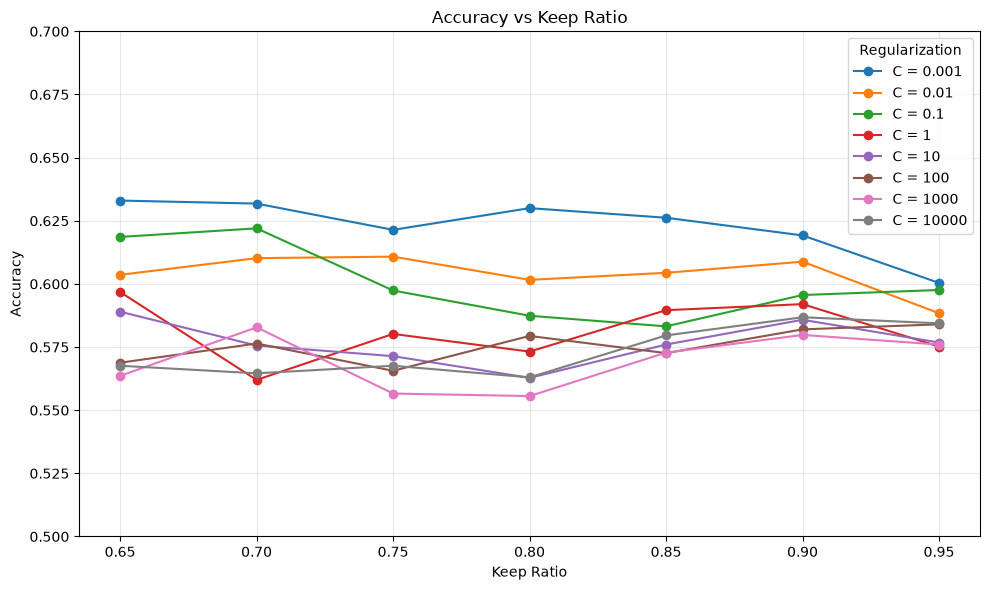

In [20]:
result_plot_df = result_rs_sc_df.map(
    lambda x: x["acc"] if isinstance(x, dict) else x
)

plt.figure(figsize=(10, 6))

for C in result_plot_df.index:
    plt.plot(
        result_plot_df.columns,
        result_plot_df.loc[C],
        marker="o",
        label=f"C = {C:g}"
    )

plt.title("Accuracy vs Keep Ratio")
plt.xlabel("Keep Ratio")
plt.ylabel("Accuracy")

plt.xticks(result_plot_df.columns)

plt.ylim(0.5, 0.7)
plt.grid(True, alpha=0.3)
plt.legend(title="Regularization")

plt.tight_layout()
plt.show()

#### 3.2.2. Heatmap

Mỗi ô là accuracy ứng với một cặp `(C, keep_ratio)` cụ thể; màu càng đậm thì accuracy càng cao — giúp xác định nhanh vùng tham số cho kết quả tốt nhất trong toàn bộ lưới.

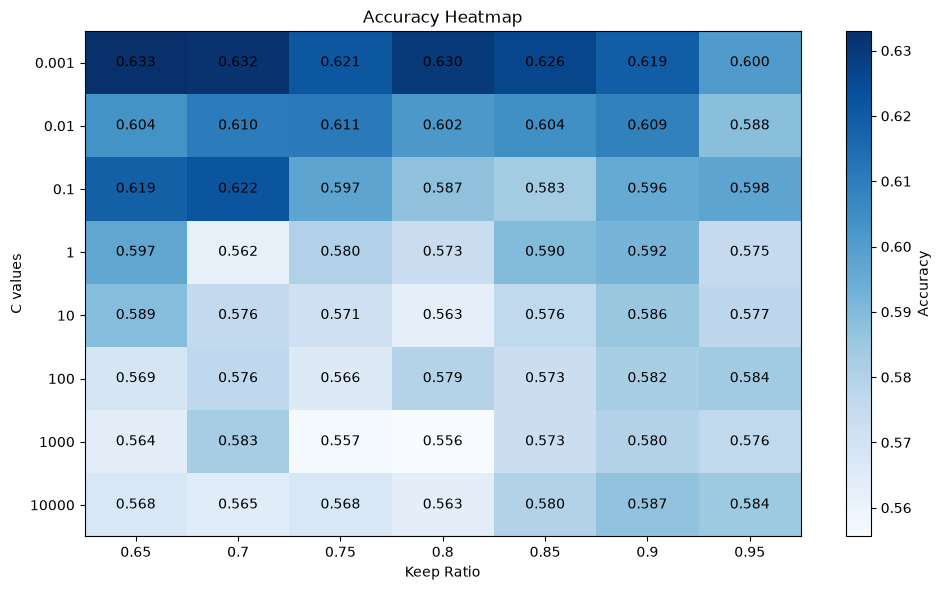

In [24]:
plt.figure(figsize=(10, 6))

plt.imshow(result_plot_df.values, aspect="auto", cmap="Blues")

plt.xticks(
    range(len(result_plot_df.columns)),
    result_plot_df.columns
)

plt.yticks(
    range(len(result_plot_df.index)),
    [f"{C:g}" for C in result_plot_df.index]
)

plt.xlabel("Keep Ratio")
plt.ylabel("C values")
plt.title("Accuracy Heatmap")

for i in range(len(result_plot_df.index)):
    for j in range(len(result_plot_df.columns)):
        value = result_plot_df.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Accuracy")
plt.tight_layout()
plt.show()

### 3.3. Kết luận

**Kết quả:** (giá trị chính xác xem heatmap ở trên; bảng dưới là trung bình theo từng `C` trên cả 7 mức `keep_ratio`)

| C | Accuracy TB (7 mức keep_ratio) | Accuracy cao nhất trong hàng |
|---|---|---|
| 10⁻³ | ≈ 0.623 | **0.633** (tại `keep_ratio = 0.65`) |
| 10⁻² | ≈ 0.604 | 0.611 |
| 10⁻¹ | ≈ 0.600 | 0.622 |
| 10⁰ | ≈ 0.581 | 0.597 |
| 10¹ | ≈ 0.577 | 0.589 |
| 10² | ≈ 0.576 | 0.584 |
| 10³ | ≈ 0.570 | 0.583 |
| 10⁴ | ≈ 0.574 | 0.587 |

Kết quả tốt nhất trong toàn bộ lưới 8×7 là **0.633**, đạt được tại `C = 0.001` và `keep_ratio = 0.65` — gần như trùng với mức tốt nhất đã quan sát được khi chỉ dùng Regularization Sweep một mình ở mục 1.3 (**≈ 0.630**, tại `C = 10⁻³`, không lọc dữ liệu). Chênh lệch chỉ **~0.3 điểm %**, nằm trong biên độ nhiễu đã quan sát được ở Self-Cleaning một mình (±1.8 điểm %, mục 2.3) — tức là **không đủ để khẳng định có hiệu ứng cộng hưởng (synergy)** thực sự giữa hai kỹ thuật.

Nhìn theo hàng (`C` cố định, quét `keep_ratio`): tại mỗi mức `C`, accuracy vẫn dao động lên xuống theo `keep_ratio` với biên độ tương tự Self-Cleaning một mình (khoảng 1–3 điểm %) — việc thêm regularization không làm cho cleaning tạo ra một xu hướng đơn điệu rõ ràng hơn.

Nhìn theo cột (`keep_ratio` cố định, quét `C`): xu hướng "C nhỏ → accuracy cao" của Regularization Sweep vẫn giữ nguyên và là **yếu tố chi phối chính** của cả lưới kết quả — accuracy trung bình giảm gần như đơn điệu từ ≈0.623 (`C = 10⁻³`) xuống còn ≈0.57–0.58 khi `C ≥ 1`, khớp với mô hình đã thấy ở mục 1.3.

→ **Kết luận cho mục 3:** với dữ liệu đầu độc 45% nhãn, việc kết hợp Self-Cleaning với Regularization **không cho thấy hiệu quả cộng hưởng rõ rệt** — kết quả tốt nhất của lưới kết hợp gần như chỉ bằng kết quả tốt nhất của Regularization Sweep một mình. Regularization (điều chỉnh `C`) vẫn là yếu tố quyết định chính đến accuracy; Self-Cleaning ở dạng hiện tại chủ yếu đóng góp nhiễu ngẫu nhiên hơn là một tín hiệu cải thiện có hệ thống, kể cả khi kết hợp với các mức regularization khác nhau.

## Kết luận

So sánh ba hướng phòng thủ đã thử nghiệm trên cùng mức đầu độc 45%:

- **Regularization Sweep** (mục 1) cho kết quả **nhất quán và dễ diễn giải**: giảm `C` (tăng regularization) cải thiện accuracy rõ rệt, từ mức thấp nhất ~55% (`C` rất lớn) lên đến ~63% ở mức regularization mạnh nhất (`C = 10⁻³`). Đây là biện pháp đơn giản, rẻ (chỉ cần đổi 1 tham số khi huấn luyện), và cho hiệu quả có thể dự đoán được.
- **Self-Cleaning** (mục 2) có tiềm năng cải thiện cao hơn về mặt lý thuyết (loại bỏ trực tiếp mẫu nhiễu thay vì chỉ kìm hãm mô hình), nhưng kết quả thực nghiệm **dao động quanh baseline** (~56–60%) mà không cho thấy xu hướng cải thiện hệ thống theo `keep_ratio`.
- **Kết hợp cả hai** (mục 3) — hướng phát triển được đặt ra ở cuối lần thử nghiệm trước — đã được kiểm chứng bằng cách quét lưới `C × keep_ratio`, nhưng **không cho thấy hiệu ứng cộng hưởng**: kết quả tốt nhất của lưới kết hợp (**≈ 0.633**) gần như chỉ ngang bằng kết quả tốt nhất khi chỉ dùng Regularization Sweep một mình (**≈ 0.630**). Regularization vẫn là yếu tố chi phối chính; việc lọc dữ liệu thêm vào không tạo ra cải thiện nằm ngoài biên độ nhiễu đã thấy ở mục 2.

Cả ba hướng đều **không đưa accuracy quay lại gần mức baseline sạch (~96%)** — cho thấy ở mức đầu độc nặng (45%), các biện pháp phòng thủ post-hoc dựa trên regularization và/hoặc lọc theo độ tin cậy dự đoán chỉ giảm thiểu được một phần thiệt hại nhỏ (tối đa ~8 điểm %), không thể vô hiệu hóa tấn công label flipping ở mức này. Một giới hạn cốt lõi có thể nằm ở chỗ `cleaning()` hiện tại dùng chính mô hình đã bị đầu độc (huấn luyện trên `X_train`/`y_train` đầy nhiễu) để tự đánh giá độ tin cậy của từng mẫu — nếu mô hình dùng để lọc đã bị lệch bởi nhãn sai, tiêu chí lọc suy ra từ nó khó có thể đáng tin cậy. Hướng phát triển hợp lý tiếp theo là các kỹ thuật **không phụ thuộc vào chính mô hình bị đầu độc** để đánh giá độ tin cậy mẫu — ví dụ Cross-Validation Filtering với nhiều mô hình khác kiến trúc, hoặc các phương pháp robust loss (Huber loss, label smoothing) chịu được nhãn nhiễu ngay trong quá trình huấn luyện thay vì lọc trước.